### Adaboost回归算法

#### 加载数据

In [5]:
import numpy as np
from sklearn.ensemble import AdaBoostRegressor
from sklearn import datasets
from sklearn import tree
import graphviz

X,y = datasets.load_boston(return_X_y=True)


d:\soft\python\396\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the California housing dataset (i.e.
  

In [10]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

In [8]:
data.shape

(506, 13)

In [9]:
target.shape

(506,)

#### 建模

In [11]:
ada = AdaBoostRegressor(n_estimators=3,loss = 'linear',# 线性，误差绝对值
                                 learning_rate=1)#learning_rate 学习率
ada.fit(X,y)#训练
y_ = ada.predict(X)#预测
print(y_[:10])


[22.9        22.9        29.85238095 29.85238095 29.85238095 22.9
 22.40669291 17.03380282 17.03380282 17.03380282]


#### 可视化

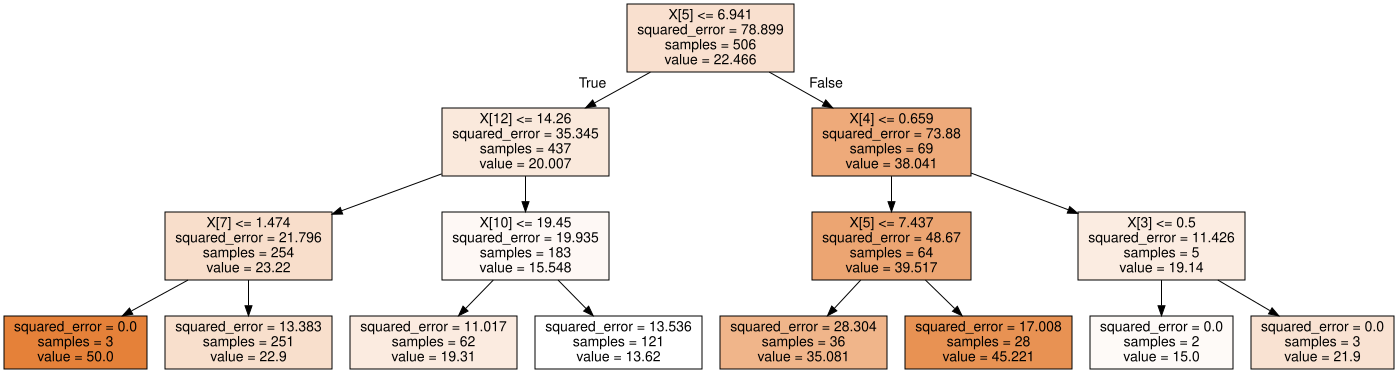

In [12]:
dot_data = tree.export_graphviz(ada[0],filled=True)
graph = graphviz.Source(dot_data)
graph


### 构建第一棵树

In [14]:
w1 = np.full(shape = 506,fill_value=1/506)
y1_ = ada[0].predict(X)

# 计算预测值和目标值的误差
error_vector = np.abs(y1_ - y)
error_max = error_vector.max()
if error_max != 0:
    error_vector /= error_max # 归一化0~1

# 计算算法误差
estimator_error = (w1 * error_vector).sum()
print('第一棵树误差：',estimator_error)
print('算法误差：',ada.estimator_errors_)

# 计算算法权重
beta = estimator_error / (1. - estimator_error)
estimator_weight =  np.log(1. / beta)
print('第一棵树权重：',estimator_weight)
print('算法权重：', ada.estimator_weights_)

# 根据第一棵树更新权重
w2 = w1 * np.power(beta, (1. - error_vector))
w2 /= w2.sum()
# 输出
# '''
# 第一棵树误差： 0.11315306016068988
# 算法误差： [0.11315306 0.11657419 0.18593167]
# 第一棵树权重： 2.0589309911688427
# 算法权重： [2.05893099 2.02527945 1.47666508]
# '''

第一棵树误差： 0.0886335703779044
算法误差： [0.08863357 0.16074995 0.18767106]
第一棵树权重： 2.330434360275974
算法权重： [2.33043436 1.65265868 1.46521462]


### 构建第二棵树

In [15]:
y2_ = ada[1].predict(X)

# 计算预测值和目标值的误差
error_vector = np.abs(y2_ - y)
error_max = error_vector.max()
if error_max != 0:
    error_vector /= error_max # 归一化

# 计算算法误差
estimator_error = (w2 * error_vector).sum()
print('第二棵树误差：',estimator_error)
print('算法误差：',ada.estimator_errors_)

# 计算算法权重
beta = estimator_error / (1. - estimator_error)
estimator_weight =  np.log(1. / beta)
print('第二棵树权重：',estimator_weight)
print('算法权重：', ada.estimator_weights_)

# 权重更新
w3 = w2 * np.power(beta, (1. - error_vector))
w3 /= w3.sum()
# 输出
# '''
# 第二棵树误差： 0.11657418722530435
# 算法误差： [0.11315306 0.11657419 0.18593167]
# 第二棵树权重： 2.0252794479876193
# 算法权重： [2.05893099 2.02527945 1.47666508]
# '''

第二棵树误差： 0.16074994561333197
算法误差： [0.08863357 0.16074995 0.18767106]
第二棵树权重： 1.6526586758771145
算法权重： [2.33043436 1.65265868 1.46521462]


### 构建第三棵树

In [17]:
y3_ = ada[2].predict(X)

# 计算预测值和目标值的误差
error_vector = np.abs(y3_ - y)
error_max = error_vector.max()
if error_max != 0:
    error_vector /= error_max

# 计算算法误差
estimator_error = (w3 * error_vector).sum()
print('第三棵树误差：',estimator_error)
print('算法误差：',ada.estimator_errors_)

# 计算算法权重
beta = estimator_error / (1. - estimator_error)
estimator_weight =  np.log(1. / beta)
print('第三棵树权重：',estimator_weight)
print('算法权重：', ada.estimator_weights_)
# 输出
# '''
# 第三棵树误差： 0.1859316681718044
# 算法误差： [0.11315306 0.11657419 0.18593167]
# 第三棵树权重： 1.4766650774202654
# 算法权重： [2.05893099 2.02527945 1.47666508]
# '''


第三棵树误差： 0.18767105821343297
算法误差： [0.08863357 0.16074995 0.18767106]
第三棵树权重： 1.4652146188730615
算法权重： [2.33043436 1.65265868 1.46521462]


### 预测值

In [18]:
ada.predict(X)[:10]

array([22.9       , 22.9       , 29.85238095, 29.85238095, 29.85238095,
       22.9       , 22.40669291, 17.03380282, 17.03380282, 17.03380282])

In [19]:
y1_ = ada[0].predict(X)[:10]
y2_ = ada[1].predict(X)[:10]
y3_ = ada[2].predict(X)[:10]
display(y1_,y2_,y3_)

array([22.9       , 22.9       , 35.08055556, 35.08055556, 35.08055556,
       22.9       , 22.9       , 19.30967742, 19.30967742, 19.30967742])

array([22.40669291, 22.40669291, 29.85238095, 29.85238095, 29.85238095,
       22.40669291, 22.40669291, 16.26770833, 16.26770833, 16.26770833])

array([27.96491228, 27.96491228, 27.96491228, 27.96491228, 27.96491228,
       27.96491228, 20.35985401, 17.03380282, 17.03380282, 17.03380282])

In [21]:
result = np.c_[y1_,y2_,y3_]
result

array([[22.9       , 22.40669291, 27.96491228],
       [22.9       , 22.40669291, 27.96491228],
       [35.08055556, 29.85238095, 27.96491228],
       [35.08055556, 29.85238095, 27.96491228],
       [35.08055556, 29.85238095, 27.96491228],
       [22.9       , 22.40669291, 27.96491228],
       [22.9       , 22.40669291, 20.35985401],
       [19.30967742, 16.26770833, 17.03380282],
       [19.30967742, 16.26770833, 17.03380282],
       [19.30967742, 16.26770833, 17.03380282]])

In [22]:
np.median(result,axis = 1)

array([22.9       , 22.9       , 29.85238095, 29.85238095, 29.85238095,
       22.9       , 22.40669291, 17.03380282, 17.03380282, 17.03380282])

### GBDT回归树预测

#### 建模

In [24]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
from sklearn import tree
import graphviz

### 实际问题，年龄预测，回归问题
# 简单的数据，算法原理，无论简单数据，还是复杂数据，都一样
# 属性一表示花销，属性二表示上网时间
X = np.array([[600,0.8],[800,1.2],[1500,10],[2500,3]])
y = np.array([14,16,24,26]) # 高一、高三，大四，工作两年
# loss  = ls 最小二乘法
learning_rate = 0.1
gbdt = GradientBoostingRegressor(n_estimators=3,loss = 'squared_error',# 最小二乘法
                                 learning_rate=0.1)#learning_rate 学习率
gbdt.fit(X,y)#训练
y_ = gbdt.predict(X)#预测
y_

array([18.374, 18.916, 21.084, 21.626])

In [40]:
gbdt.predict([[605,0.75]]) # 测试数据

array([18.374])

#### 计算残差

In [25]:
# 目标值，真实值，算法，希望，预测，越接近真实，模型越好！！！
print(y)
# 求平均，这个平均值就是算法第一次预测的基准，初始值
print(y.mean())
# 残差：真实值，和预测值之间的差
residual = y - y.mean()
residual
# 残差，越小越好
# 如果残差是0，算法完全准确的把数值预测出来！


[14 16 24 26]
20.0


array([-6., -4.,  4.,  6.])

#### 可视化第一课树

均方误差： 26.0


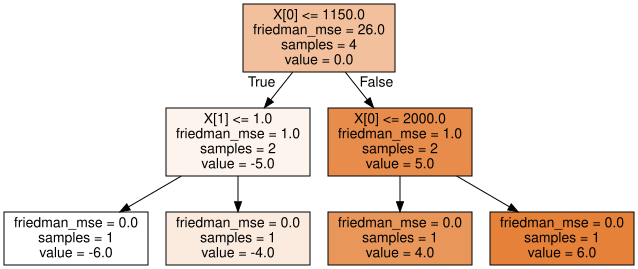

In [26]:
# 第一颗树，分叉时，friedman-mse (就是均方误差)= 26
print('均方误差：',((y - y.mean())**2).mean())
dot_data = tree.export_graphviz(gbdt[0,0],filled=True)
graph = graphviz.Source(dot_data)
graph

In [30]:
residual -= residual * learning_rate
residual

array([-5.4, -3.6,  3.6,  5.4])

In [31]:
(residual**2).mean()

21.060000000000002

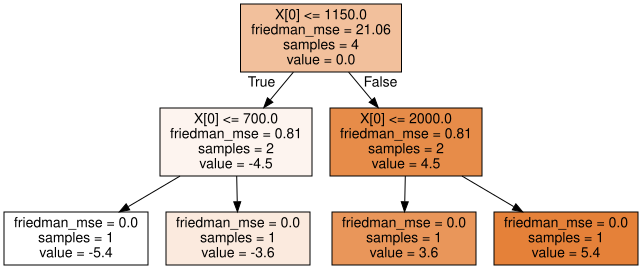

In [28]:
# 第二棵树
dot_data = tree.export_graphviz(gbdt[1,0],filled=True)
graph = graphviz.Source(dot_data)
graph

In [33]:
residual -= residual * learning_rate
residual

array([-4.86, -3.24,  3.24,  4.86])

In [36]:
np.round((residual**2).mean(),3)

17.059

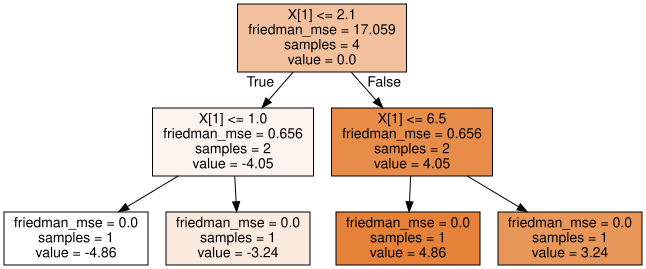

In [32]:
# 第三棵树
dot_data = tree.export_graphviz(gbdt[2,0],filled=True)
graph = graphviz.Source(dot_data)
graph

In [37]:
residual

array([-4.86, -3.24,  3.24,  4.86])

In [38]:
residual -= residual * learning_rate
residual

array([-4.374, -2.916,  2.916,  4.374])

In [39]:
y - residual

array([18.374, 18.916, 21.084, 21.626])

In [41]:
gbdt.predict(X)

array([18.374, 18.916, 21.084, 21.626])

### XGBoost 用法之一

In [44]:
from sklearn.ensemble import GradientBoostingClassifier,GradientBoostingRegressor

In [45]:
import numpy as np
import xgboost as xgb
from xgboost import XGBClassifier,XGBRFRegressor
from sklearn import datasets
from sklearn import tree
from sklearn.model_selection import train_test_split
X,y = datasets.load_wine(return_X_y=True) # 葡萄酒数据

In [48]:
y # 三分类

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [71]:
model = XGBClassifier(learning_rate =0.1,# 学习率，控制每次迭代更新权重时的步长，默认0.3。值越小，训练越慢。
                      n_estimators=100,# 总共迭代的次数，即决策树的个数
                      early_stopping_rounds = 10,
                      max_depth=5, # 深度
                      min_child_weight=1,# 默认值为1,。值越大，越容易欠拟合；值越小，越容易过拟合
                      gamma=0,# 惩罚项系数，指定节点分裂所需的最小损失函数下降值。
                      subsample=0.8,# 训练每棵树时，使用的数据占全部训练集的比例。默认值为1，典型值为0.5-1。防止overfitting。
                      colsample_bytree=0.8,
                      objective= 'binary:logistic',# 目标函数
                      eval_metric = ['merror'],# 验证数据集评判标准
                      nthread=4,verbosity = 3)# 并行线程数

In [72]:
eval_set = [(X_test, y_test),(X_train,y_train)]
model.fit(X_train,y_train,eval_set = eval_set,verbose = True,)
model.score(X_test,y_test)

[21:51:42] DEBUG: C:/Users/Administrator/workspace/xgboost-win64_release_1.6.0/src/gbm/gbtree.cc:155: Using tree method: 2
[21:51:42] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.6.0/src/tree/updater_prune.cc:101: tree pruning end, 6 extra nodes, 0 pruned nodes, max_depth=3
[21:51:42] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.6.0/src/tree/updater_prune.cc:101: tree pruning end, 8 extra nodes, 0 pruned nodes, max_depth=4
[21:51:42] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.6.0/src/tree/updater_prune.cc:101: tree pruning end, 6 extra nodes, 0 pruned nodes, max_depth=2
[0]	validation_0-merror:0.00000	validation_1-merror:0.00704
[21:51:42] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.6.0/src/tree/updater_prune.cc:101: tree pruning end, 6 extra nodes, 0 pruned nodes, max_depth=3
[21:51:42] INFO: C:/Users/Administrator/workspace/xgboost-win64_release_1.6.0/src/tree/updater_prune.cc:101: tree pruning end, 12 extra n

0.9722222222222222

In [52]:
eval_set = [(X_test, y_test)]
model.fit(X_train,y_train,eval_set = eval_set,verbose = True)
model.score(X_test,y_test)

[0]	validation_0-merror:0.00000
[1]	validation_0-merror:0.02778
[2]	validation_0-merror:0.05556
[3]	validation_0-merror:0.02778
[4]	validation_0-merror:0.05556
[5]	validation_0-merror:0.05556
[6]	validation_0-merror:0.05556
[7]	validation_0-merror:0.05556
[8]	validation_0-merror:0.05556
[9]	validation_0-merror:0.05556


0.9444444444444444

In [51]:
eval_set = [(X_test, y_test),(X_train,y_train)]
model.fit(X_train,y_train,eval_set = eval_set,verbose = False)
model.score(X_test,y_test)

0.9444444444444444

### XGBoost使用方式之二

In [77]:
X,y = datasets.load_wine(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

param = {'learning_rate':0.1,'n_estimators':10000,
         'max_depth':5,'min_child_weight':1,'gamma':0,'subsample':0.8,
         'colsample_bytree':0.8, 'verbosity':0,'objective':'multi:softprob',
         'eval_metric':'merror','early_stopping_rounds':20}

model = xgb.XGBClassifier(**param)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
model.score(X_test,y_test)

[0]	validation_0-merror:0.13889
[1]	validation_0-merror:0.16667
[2]	validation_0-merror:0.11111
[3]	validation_0-merror:0.11111
[4]	validation_0-merror:0.08333
[5]	validation_0-merror:0.08333
[6]	validation_0-merror:0.08333
[7]	validation_0-merror:0.08333
[8]	validation_0-merror:0.08333
[9]	validation_0-merror:0.08333
[10]	validation_0-merror:0.08333
[11]	validation_0-merror:0.05556
[12]	validation_0-merror:0.05556
[13]	validation_0-merror:0.05556
[14]	validation_0-merror:0.05556
[15]	validation_0-merror:0.05556
[16]	validation_0-merror:0.05556
[17]	validation_0-merror:0.05556
[18]	validation_0-merror:0.05556
[19]	validation_0-merror:0.05556
[20]	validation_0-merror:0.05556
[21]	validation_0-merror:0.05556
[22]	validation_0-merror:0.05556
[23]	validation_0-merror:0.05556
[24]	validation_0-merror:0.05556
[25]	validation_0-merror:0.05556
[26]	validation_0-merror:0.05556
[27]	validation_0-merror:0.05556
[28]	validation_0-merror:0.05556
[29]	validation_0-merror:0.05556
[30]	validation_0-me

0.9444444444444444

### XGBoost使用方式之三

In [90]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn import datasets
X,y = datasets.load_wine(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# 创建数据
dtrain = xgb.DMatrix(data = X_train,label = y_train)
dtest = xgb.DMatrix(data = X_test,label = y_test)


# 指定参数
param = {'learning_rate':0.1,'max_depth':5,
         'min_child_weight':1,'gamma':0,'subsample':0.8,'eval_metric':['merror'],
         'colsample_bytree':0.1, 'verbosity':0,'objective':'multi:softmax','num_class':3}

num_round = 100
evals = [(dtest,'eval')] # 评估

# 直接调用模块的train函数，进行了建模
model = xgb.train(param, dtrain,num_round,evals = evals,early_stopping_rounds=10)

# 进行预测
y_ = model.predict(dtest)
display(y_,accuracy_score(y_test,y_))

[0]	eval-merror:0.13889
[1]	eval-merror:0.02778
[2]	eval-merror:0.08333
[3]	eval-merror:0.05556
[4]	eval-merror:0.05556
[5]	eval-merror:0.02778
[6]	eval-merror:0.11111
[7]	eval-merror:0.11111
[8]	eval-merror:0.08333
[9]	eval-merror:0.02778
[10]	eval-merror:0.05556
[11]	eval-merror:0.05556


array([2., 1., 0., 1., 1., 0., 0., 0., 2., 1., 0., 1., 0., 0., 0., 0., 0.,
       2., 1., 1., 0., 1., 1., 2., 2., 1., 2., 2., 2., 1., 2., 0., 0., 1.,
       0., 1.], dtype=float32)

0.9444444444444444